In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

# Carga de la base de datos

In [12]:
df = pd.read_excel("Mexico GDP.xlsx")
df.head(10)

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10
5,1965,2.184000e+10
6,1966,2.432000e+10
7,1967,2.656000e+10
8,1968,2.936000e+10
9,1969,3.248000e+10


# Grafico de dispersion

Text(0.5, 0, 'Periodo')

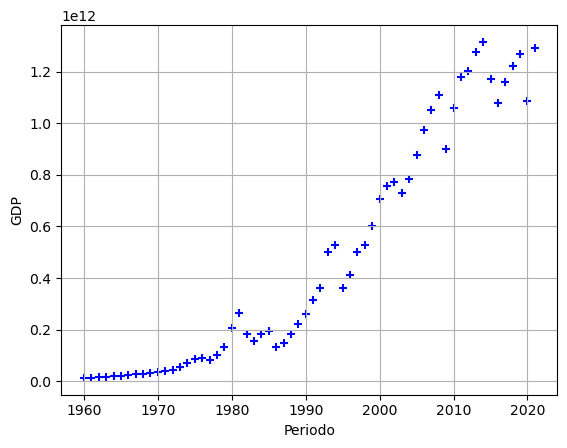

In [14]:
plt.scatter(df.Periodo, df.GDP, marker='+', color='blue')
plt.grid()
plt.ylabel('GDP')
plt.xlabel('Periodo')

# Normalizacion de datos

In [16]:
x = np.asanyarray(df.Periodo)
y = np.asanyarray(df.GDP)

In [18]:
x_norm = x / x.max()
y_norm = y / y.max()

# Ajuste del modelo

In [20]:
from scipy.special import expit

def sigmoide(x, b1, b2):
    return expit(b1*(x - b2))

In [22]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(sigmoide, x_norm, y_norm)
b1, b2 = popt

# Grafica del modelo ajustado

In [24]:
y_pred = sigmoide(x_norm, b1, b2)

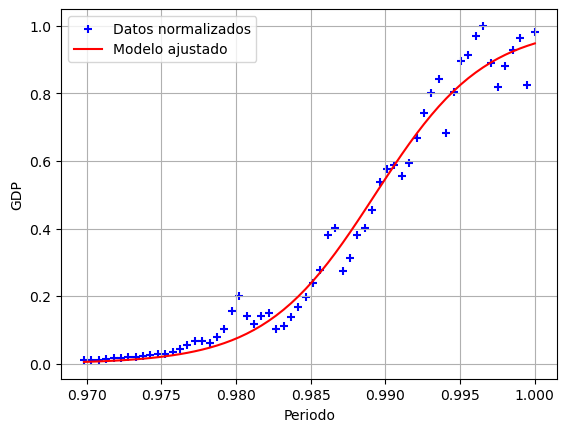

In [26]:
plt.scatter(x_norm, y_norm, label='Datos normalizados', marker='+', color='blue')
plt.plot(x_norm, y_pred, color='red', label='Modelo ajustado')
plt.legend()
plt.grid()
plt.ylabel('GDP')
plt.xlabel('Periodo')
plt.show()

# Pronostico 2022

In [28]:
x_2022_norm = 2022 / x.max()
pred_2022 = sigmoide(x_2022_norm, b1, b2)
pred_2022*y.max()

1255426603076.2312

# Bondad de ajuste

In [30]:
from sklearn.metrics import r2_score
r2 = r2_score(y_norm, y_pred)
r2

0.9780236969971561